# HLO analysis & Shardy experiment

Run `exploration.ipynb` first to confirm the regression is isolated
to `matrix.cholesky` for `quasisep_matern52_cpu`.

## Background

XLA compiles JAX programs to HLO (High-Level Operations) before generating native
code. JAX exposes the full AOT (ahead-of-time) compilation pipeline through its
`jax.stages` API:

```
jax.jit(f).trace(...)    →  Jaxpr        (JAX's own IR; Python eliminated)
          .lower()       →  StableHLO    (XLA's stable input language, pre-optimization)
          .compile()     →  XLA HLO      (post-optimization, target-specific)
          (x, y)         →  execute on device
```

**The StableHLO is where JAX's lowering changes are visible.** Comparing
`.lower().as_text()` between two JAX versions shows exactly what XLA is handed
differently. If the regression is in XLA's code generation for the Cholesky scan,
it should be visible as a difference here.

The `lax.scan` compiles to an XLA `while` op. Key things to look for in a diff:
- Changes in how the `while` loop body is structured
- Loop-invariant values that are now threaded through as outputs instead of constants
- Different matrix op lowerings inside the loop body

**Note:** cells that run JAX use whatever version is installed in `.venv`.
Run `uv sync --extra jax0431` or `uv sync --extra jax091` before launching
the kernel to control which version you see.

In [3]:
import json, os, subprocess
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## HLO comparison: `matrix.cholesky` between JAX versions

To generate the HLO dumps for the tinygp solver, run from the project root:

```bash
uv sync --extra jax0431
uv run python -m benchmarks.dump_hlo --size 500 --output results/hlo-jax0431

uv sync --extra jax091
uv run python -m benchmarks.dump_hlo --size 500 --output results/hlo-jax091
```

The cell below reads both dumps and shows a unified diff of the pre-optimisation
StableHLO. Focus on the `quasisep_matern52_cpu` output — that's where the
regression lives.

In [13]:
import difflib
from pathlib import Path

SCENARIO = "quasisep_matern52_cpu"
results_dir = Path().resolve().parent / "results"
baseline_path = results_dir / "hlo-jax0431" / f"{SCENARIO}.txt"
candidate_path = results_dir / "hlo-jax091" / f"{SCENARIO}.txt"

if not baseline_path.exists() or not candidate_path.exists():
    print("HLO dump files not found. Run the dump_hlo commands above first.")
else:
    baseline_lines = baseline_path.read_text().splitlines(keepends=True)
    candidate_lines = candidate_path.read_text().splitlines(keepends=True)

    diff = list(
        difflib.unified_diff(
            baseline_lines,
            candidate_lines,
            fromfile=f"jax0431/{SCENARIO}",
            tofile=f"jax091/{SCENARIO}",
            n=3,
        )
    )

    if not diff:
        print("No differences found between the two HLO dumps.")
    else:
        plain = "".join(diff)
        print(f"{len(diff)} diff lines across {sum(1 for l in diff if l.startswith('@@'))} hunks\n")

        # Coloured output for notebook readability
        for i, line in enumerate(diff):
            if i > 50:
                print("... (truncated for brevity) ...")
                break
            if line.startswith("+++") or line.startswith("---"):
                print(f"\033[1m{line}\033[0m", end="")
            elif line.startswith("+"):
                print(f"\033[32m{line}\033[0m", end="")
            elif line.startswith("-"):
                print(f"\033[31m{line}\033[0m", end="")
            elif line.startswith("@@"):
                print(f"\033[36m{line}\033[0m", end="")
            else:
                print(line, end="")

425 diff lines across 3 hunks

--- jax0431/quasisep_matern52_cpu
+++ jax091/quasisep_matern52_cpu
@@ -1,17 +1,18 @@
 scenario:  quasisep_matern52_cpu
-jax:       0.4.31
+jax:       0.9.1
 n:         500
 
 PRE-OPTIMIZATION (StableHLO from .lower().as_text())
 
-module @jit__lambda_ attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
-  func.func public @main(%arg0: tensor<500xf64> {mhlo.layout_mode = "{0}", mhlo.sharding = "{replicated}"}, %arg1: tensor<500x3xf64> {mhlo.layout_mode = "{1,0}", mhlo.sharding = "{replicated}"}, %arg2: tensor<500x3xf64> {mhlo.layout_mode = "{1,0}", mhlo.sharding = "{replicated}"}, %arg3: tensor<500x3x3xf64> {mhlo.layout_mode = "{2,1,0}", mhlo.sharding = "{replicated}"}) -> (tensor<500xf64> {jax.result_info = ".diag.d", mhlo.layout_mode = "default"}, tensor<500x3xf64> {jax.result_info = ".lower.p", mhlo.layout_mode = "default"}, tensor<500x3xf64> {jax.result_info = ".lower.q", mhlo.layout_mode = "default"}, tensor<500x3x3xf64> {jax.res

### 1. Pre-optimization: bounds-checking was removed (good change)
JAX 0.4.31 emitted 4 extra operations per dynamic_slice inside the loop body — a negative-index bounds check that was always a no-op (the while loop counter is already bounded to [0, 500)):
```
compare LT, index, 0        # always false
add index, 500              # dead computation
select(compare, add, index) # always takes the original index
```
This appeared 4 times per iteration (once for d, p, q, a slices). JAX 0.9.1 removed all of this. So the pre-optimization HLO is actually cleaner in 0.9.1 — fewer operations per loop step.

### 2. Pre-optimization: cholesky return signature changed
JAX 0.4.31's `@cholesky` function returned only the 2 computed outputs `(c, w)`. The unchanged inputs `p` and `a` were passed around it directly in `@main`:

`return %0#0, %arg1, %0#1, %arg3   // p and a bypass cholesky entirely`

JAX 0.9.1's `@cholesky` returns all 4 values including the unchanged `p` and `a`:

`return %0#0, %0#1, %0#2, %0#3     // everything goes through cholesky`

This means XLA in 0.9.1 sees `p` and `a` as outputs of the while loop, not as loop-invariant inputs that can be hoisted. This likely interferes with XLA's loop invariant code motion.

### 3. Post-optimization: the loop increment is now a wrapped computation
JAX 0.4.31 inlined the counter increment directly:
```
%constant.43 = s64[] constant(1)
%add.80 = s64[] add(%copy.6, %constant.43)
```
JAX 0.9.1 wraps it in a separate computation:
```
%wrapped_add_computation ... { ROOT add }
%wrapped_add = s64[] fusion(...), kind=kLoop, calls=%wrapped_add_computation
```
A separate fusion kernel for a scalar add is overhead.

### 4. New Shardy sharding dialect
JAX 0.9.1 introduces `sdy.mesh @empty_mesh = <[]>` and Shardy sharding annotations on every tensor, even for single-device CPU. This represents a significant change to XLA's pre-processing passes.

### Summary
The pre-optimization HLO is actually leaner in JAX 0.9.1 (the bounds-check noise is gone). But XLA produces slower machine code from it — likely due to the return signature change (breaking loop invariant analysis for `p` and `a`) and/or the new Shardy pipeline.

## Shardy experiment: does disabling the new sharding dialect fix the regression?

The HLO diff showed that JAX 0.9.1 switched to the Shardy sharding dialect (`sdy.mesh @empty_mesh`) even for single-device CPU. This changes XLA's compilation pipeline and is a candidate for the regression.

`JAX_USE_SHARDY_PARTITIONER=0` reverts to the old mhlo sharding annotations. It must be set **before** JAX is imported, so we run it as a subprocess rather than in-process.

The cell below runs the full smoke breakdown with that flag set, saves the result, and then plots `matrix.cholesky` timings for all three versions side by side for `quasisep_matern52_cpu`:

- **jax0431**: baseline
- **jax091 (Shardy on)**: the regression we measured
- **jax091 (Shardy off)**: what we're testing now

If the Shardy-off line matches the 0.4.31 baseline, the Shardy pipeline is the root cause.

In [3]:
import subprocess, os, json
from pathlib import Path

PROJECT_ROOT = Path("..").resolve()
NOSHARDY_OUTPUT = Path("jax091-noshardy-breakdown.json")

if NOSHARDY_OUTPUT.exists():
    print(f"Found existing {NOSHARDY_OUTPUT}, skipping re-run. Delete it to force a fresh run.")
else:
    print("Running breakdown with JAX_USE_SHARDY_PARTITIONER=0 ...")
    env = {**os.environ, "JAX_USE_SHARDY_PARTITIONER": "0"}
    result = subprocess.run(
        ["uv", "run", "python", "-m", "benchmarks.breakdown",
         "--profile", "smoke",
         "--output", str(PROJECT_ROOT / "results" / NOSHARDY_OUTPUT)],
        env=env, cwd=PROJECT_ROOT, capture_output=True, text=True,
    )
    if result.returncode != 0:
        print("STDERR:", result.stderr[-2000:])
        raise RuntimeError("Breakdown subprocess failed")
    print("Done.")

with open("jax0431-breakdown.json") as f:
    r0431 = json.load(f)
with open("jax091-breakdown.json") as f:
    r091 = json.load(f)
with open(NOSHARDY_OUTPUT) as f:
    r091_ns = json.load(f)

print(f"jax0431          JAX {r0431['jax']}")
print(f"jax091           JAX {r091['jax']}  (Shardy on)")
print(f"jax091-noshardy  JAX {r091_ns['jax']}  (Shardy off)")

Found existing jax091-noshardy-breakdown.json, skipping re-run. Delete it to force a fresh run.
jax0431          JAX 0.4.31
jax091           JAX 0.9.1  (Shardy on)
jax091-noshardy  JAX 0.9.1  (Shardy off)


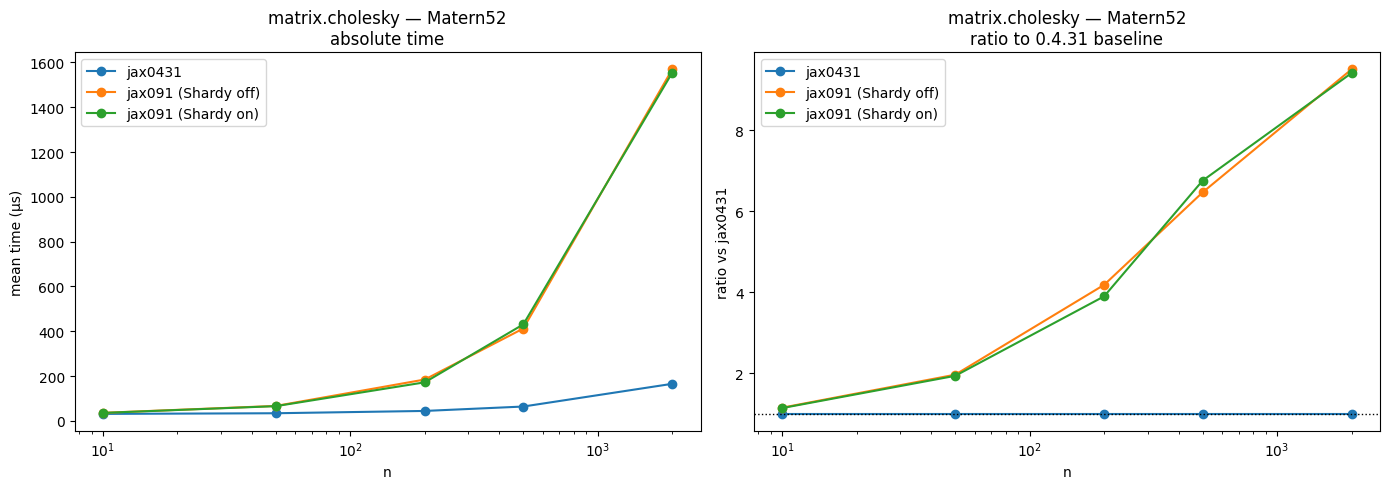

,jax0431,jax091 (Shardy off),jax091 (Shardy on)
n,,,
10,30.9,35.6,35.3
50,33.8,66.4,65.5
200,44.1,184.4,171.9
500,63.7,412.0,430.4
2000,165.2,1569.0,1553.9


In [4]:
def to_df(payload, label):
    df = pd.DataFrame(payload["results"])
    df["version"] = label
    return df

df_all = pd.concat(
    [to_df(r0431, "jax0431"),
     to_df(r091, "jax091 (Shardy on)"),
     to_df(r091_ns, "jax091 (Shardy off)")],
    ignore_index=True,
)

chol = df_all[(df_all["stage"] == "matrix.cholesky") & (df_all["scenario"] == "quasisep_matern52_cpu")].copy()
chol["mean_us"] = chol["mean_s"] * 1e6

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for version, grp in chol.groupby("version"):
    grp = grp.sort_values("n")
    ax.plot(grp["n"], grp["mean_us"], "o-", label=version)
ax.set_xlabel("n")
ax.set_ylabel("mean time (μs)")
ax.set_title("matrix.cholesky — Matern52\nabsolute time")
ax.set_xscale("log")
ax.legend()

ax = axes[1]
baseline = chol[chol["version"] == "jax0431"].set_index("n")["mean_s"]
for version, grp in chol.groupby("version"):
    grp = grp.sort_values("n")
    ratio = grp.set_index("n")["mean_s"] / baseline
    ax.plot(ratio.index, ratio.values, "o-", label=version)
ax.axhline(1.0, color="k", linestyle=":", linewidth=1)
ax.set_xlabel("n")
ax.set_ylabel("ratio vs jax0431")
ax.set_title("matrix.cholesky — Matern52\nratio to 0.4.31 baseline")
ax.set_xscale("log")
ax.legend()

plt.tight_layout()
plt.show()

pivot = chol.pivot(index="n", columns="version", values="mean_us").round(1)
pivot.columns.name = None
display(pivot)

## HLO for the minimal reproducer

For the issue we will raise in the JAX repo, we want to reproduce this behavior
with a more minimal script, with no tinygp dependency. 

We shall also generate the HLO diff for this snippet we'll use, so we can
include that in the bug report as well.

The minimal reproducer is:

In [14]:
"""Run on both JAX versions to reproduce the regression."""

import statistics, time
import jax, jax.numpy as jnp

jax.config.update("jax_enable_x64", True)

N, M, SAMPLES = 2000, 3, 200

key = jax.random.PRNGKey(0)
dtype = jnp.float64  # change to jnp.float32 to confirm it is unaffected

d = jax.random.uniform(key, (N,), dtype=dtype, minval=1.0, maxval=2.0)
p = jax.random.normal(key, (N, M), dtype=dtype) * 0.1
q = jax.random.normal(key, (N, M), dtype=dtype) * 0.1
a = jax.random.normal(key, (N, M, M), dtype=dtype) * 0.1
init = jnp.zeros((M, M), dtype=dtype)


def body(carry, data):
    fp = carry
    dk, pk, qk, ak = data
    ck = jnp.sqrt(dk - pk @ fp @ pk)
    tmp = fp @ ak.T
    wk = (qk - pk @ tmp) / ck
    return ak @ tmp + jnp.outer(wk, wk), (ck, wk)

scan_fn = lambda: jax.lax.scan(body, init, (d, p, q, a))
compiled = jax.jit(scan_fn).lower().compile()
jax.block_until_ready(compiled())  # warmup

ts = []
for _ in range(SAMPLES):
    t0 = time.perf_counter()
    jax.block_until_ready(compiled())
    ts.append(time.perf_counter() - t0)

print(f"JAX {jax.__version__}  dtype={dtype}  n={N}  m={M}  median={statistics.median(ts)*1e6:.1f} µs")

JAX 0.4.31  dtype=<class 'jax.numpy.float64'>  n=2000  m=3  median=137.8 µs


### Step 1 — Trace: JAX traces the Python function to a Jaxpr

We will take this time to walk through the stages of the AOT compilation pipeline.

The Jaxpr is JAX's own intermediate representation — a purely functional, typed expression language.
It is independent of XLA and shows the computation after Python has been eliminated.
The scan body appears as a closed-form expression over abstract values.

In [17]:
traced = jax.jit(scan_fn).trace()
print(traced.jaxpr)

{ lambda a:f64[3,3] b:f64[2000] c:f64[2000,3] d:f64[2000,3] e:f64[2000,3,3]; . let
    f:f64[3,3] g:f64[2000] h:f64[2000,3] = scan[
      _split_transpose=False
      jaxpr={ lambda ; i:f64[3,3] j:f64[] k:f64[3] l:f64[3] m:f64[3,3]. let
          n:f64[3] = dot_general[
            dimension_numbers=(([0], [0]), ([], []))
            preferred_element_type=float64
          ] k i
          o:f64[] = dot_general[
            dimension_numbers=(([0], [0]), ([], []))
            preferred_element_type=float64
          ] n k
          p:f64[] = sub j o
          q:f64[] = sqrt p
          r:f64[3,3] = transpose[permutation=(1, 0)] m
          s:f64[3,3] = dot_general[
            dimension_numbers=(([1], [0]), ([], []))
            preferred_element_type=float64
          ] i r
          t:f64[3] = dot_general[
            dimension_numbers=(([0], [0]), ([], []))
            preferred_element_type=float64
          ] k s
          u:f64[3] = sub l t
          v:f64[3] = div u q
          

### Step 2 — Lower: the Jaxpr is lowered to StableHLO

StableHLO is XLA's stable, versioned input language. This is the representation that
**differs between JAX versions** — changes in JAX's lowering pass are visible here.
The `lax.scan` becomes an XLA `while` op with an explicit loop body and condition function.

This is the text we diff to understand what JAX changed between 0.4.31 and 0.9.1.

In [18]:
lowered = traced.lower()
print(lowered.as_text())

module @jit__lambda_ attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
  func.func public @main() -> (tensor<3x3xf64> {jax.result_info = "[0]", mhlo.layout_mode = "default"}, tensor<2000xf64> {jax.result_info = "[1][0]", mhlo.layout_mode = "default"}, tensor<2000x3xf64> {jax.result_info = "[1][1]", mhlo.layout_mode = "default"}) {
    %cst = stablehlo.constant dense<0.000000e+00> : tensor<3x3xf64>
    %cst_0 = stablehlo.constant dense<"..."> : tensor<2000xf64>
    %cst_1 = stablehlo.constant dense<"..."> : tensor<2000x3xf64>
    %cst_2 = stablehlo.constant dense<"..."> : tensor<2000x3xf64>
    %cst_3 = stablehlo.constant dense<"..."> : tensor<2000x3x3xf64>
    %cst_4 = stablehlo.constant dense<0.000000e+00> : tensor<f64>
    %0 = stablehlo.broadcast_in_dim %cst_4, dims = [] : (tensor<f64>) -> tensor<2000xf64>
    %cst_5 = stablehlo.constant dense<0.000000e+00> : tensor<f64>
    %1 = stablehlo.broadcast_in_dim %cst_5, dims = [] : (tensor<f64>) -> tensor<2000x3xf6

### Step 3 — Compile: XLA optimizes and generates machine code

The compiled HLO shows the result after XLA's optimization passes (fusion, constant folding,
loop invariant code motion, etc.). Differences here reveal what XLA's backend does differently
with the two StableHLO inputs — even if the inputs look similar, XLA may produce very
different native code.

Cost analysis provides FLOP counts and memory estimates from the compiler.

In [20]:
compiled = lowered.compile()

try:
    print(compiled.as_text())
except AttributeError:
    print('Post-optimization HLO not available in this JAX version.')

HloModule jit__lambda_, is_scheduled=true, entry_computation_layout={()->(f64[3,3]{1,0}, f64[2000]{0}, f64[2000,3]{1,0})}, allow_spmd_sharding_propagation_to_output={true,true,true}

%fused_computation (param_0: f64[2000,3], param_1.1: s64[], param_2.2: f64[3]) -> f64[2000,3] {
  %param_0 = f64[2000,3]{1,0} parameter(0)
  %param_2.2 = f64[3]{0} parameter(2)
  %bitcast.5 = f64[1,3]{1,0} bitcast(f64[3]{0} %param_2.2), metadata={op_name="jit(<lambda>)/jit(main)/while/body/div" source_file="/var/folders/jz/hxf8drjs3cb5xj9dwfn4xphm0000gn/T/ipykernel_95925/2470769769.py" source_line=25}
  %param_1.1 = s64[] parameter(1)
  %constant.0 = s64[] constant(0)
  ROOT %dynamic-update-slice.0 = f64[2000,3]{1,0} dynamic-update-slice(f64[2000,3]{1,0} %param_0, f64[1,3]{1,0} %bitcast.5, s64[] %param_1.1, s64[] %constant.0), metadata={op_name="jit(<lambda>)/jit(main)/while/body/dynamic_update_slice" source_file="/var/folders/jz/hxf8drjs3cb5xj9dwfn4xphm0000gn/T/ipykernel_95925/2470769769.py" source_line=2

### Cross-version diff

To produce the diff that goes into the GitHub issue, run `dump_hlo_repro.py` once per
JAX version from the project root, then diff the outputs:

```bash
uv sync --extra jax0431
uv run python -m benchmarks.dump_hlo_repro --output results/hlo-repro-jax0431.txt

uv sync --extra jax091
uv run python -m benchmarks.dump_hlo_repro --output results/hlo-repro-jax091.txt

# plain-text diff — pipe to file, then copy/paste into GitHub
uv run python -m benchmarks.dump_hlo_repro \
    --diff results/hlo-repro-jax0431.txt results/hlo-repro-jax091.txt \
    > results/hlo-repro-diff.txt
```

The cell below loads the diff file and prints it — scroll the output to review before pasting.

In [22]:
from pathlib import Path

results_dir = Path().resolve().parent / "results"
diff_path = results_dir / "hlo-repro-diff.txt"

if not diff_path.exists():
    print("hlo-repro-diff.txt not found. Run the dump_hlo_repro commands above first.")
else:
    text = diff_path.read_text()
    print(text)

117 diff lines across 1 chunks

--- results/hlo-repro-jax0431.txt
+++ results/hlo-repro-jax091.txt
@@ -1,87 +1,51 @@
-jax:   0.4.31
+jax:   0.9.1
 n:     2000
 m:     3
 dtype: <class 'jax.numpy.float64'>
 
-module @jit__lambda_ attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
-  func.func public @main() -> (tensor<3x3xf64> {jax.result_info = "[0]", mhlo.layout_mode = "default"}, tensor<2000xf64> {jax.result_info = "[1][0]", mhlo.layout_mode = "default"}, tensor<2000x3xf64> {jax.result_info = "[1][1]", mhlo.layout_mode = "default"}) {
+module @jit__lambda attributes {mhlo.num_partitions = 1 : i32, mhlo.num_replicas = 1 : i32} {
+  func.func public @main() -> (tensor<3x3xf64> {jax.result_info = "result[0]"}, tensor<2000xf64> {jax.result_info = "result[1][0]"}, tensor<2000x3xf64> {jax.result_info = "result[1][1]"}) {
     %cst = stablehlo.constant dense<0.000000e+00> : tensor<3x3xf64>
-    %cst_0 = stablehlo.constant dense<"..."> : tensor<2000xf64>
-    %cst_1 = 